# Posture detector comparison inside STUDD

This notebook compares different drift detectors inside the STUDD mechanism on the Posture dataset.

The Posture stream contains sensor measurements from five different people. The task is to predict the performed movement among 11 classes.

Αs in the Electricity and Covtype experiments, we use the first alarm produced by a supervised signal detector (SS) as a reference drift indication.

For each STUDD detector, we record:

- all STUDD alarms
- the STUDD alarm closest to the first SS alarm
- detection delay relative to the first SS alarm
- teacher-student disagreement around the first SS alarm
- teacher-student disagreement around the closest STUDD alarm

In [13]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from capymoa.stream import NumpyStream

from capymoa.drift.detectors import (
    STUDD,
    ADWIN,
    PageHinkley,
    HDDMAverage,
    HDDMWeighted,
    CUSUM,
)

from helpers import (
    configure_matplotlib,
    rolling_mean,
)

from studd_utils import (
    make_teacher,
    make_student,
)

configure_matplotlib()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Posture data

The dataset is stored as a comma-separated `.data` file.

The first three columns are numerical sensor features and the last column is the class label.

In [14]:
DATA_PATH = "data/Posture.data"

df = pd.read_csv(
    DATA_PATH,
    header=None,
)

X = df.iloc[:, :-1].to_numpy(dtype=float)

y_raw = df.iloc[:, -1].astype(str)

y_codes, class_names = pd.factorize(y_raw)

y = y_codes.astype(int)

print("Shape:", df.shape)
print("Classes:")
print(pd.Series(y_raw).value_counts())
print()
print("Encoded classes:")
for class_id, class_name in enumerate(class_names):
    print(class_id, "->", class_name)

Shape: (164860, 4)
Classes:
3
lying                                     54480
walking                                   32710
sitting                                   27244
standing up from lying                    18361
sitting on the ground                     11779
lying down                                 6168
on all fours                               5210
falling                                    2973
standing up from sitting on the ground     2848
sitting down                               1706
standing up from sitting                   1381
Name: count, dtype: int64

Encoded classes:
0 -> sitting on the ground
1 -> lying
2 -> sitting
3 -> sitting down
4 -> standing up from lying
5 -> walking
6 -> lying down
7 -> falling
8 -> on all fours
9 -> standing up from sitting on the ground
10 -> standing up from sitting


## Experimental parameters

The full Posture stream is used.

The teacher is trained on the first `W` labeled samples and remains fixed during monitoring.

The student learns online to mimic the teacher.

The supervised signal detector monitors the teacher prediction error and provides a reference alarm.

In [15]:
SEED = 1

N_STREAM = 164860
W = 2000

N_TREES = 100
PH_DELTA = 0.001

TEACHER_TYPE = "sgbt"
STUDENT_TYPE = "rf"

LOCAL_WINDOW = 100
ROLLING_WINDOW = 200

## Detectors

We compare the same five detectors used in the other detector-comparison notebooks.

Page-Hinkley is configured with `delta = 0.001`.

In [16]:
DETECTORS = {
    "ADWIN": lambda: ADWIN(),
    "PageHinkley": lambda: PageHinkley(delta=PH_DELTA),
    "HDDMAverage": lambda: HDDMAverage(test_type="One-sided"),
    "HDDMWeighted": lambda: HDDMWeighted(test_type="One-sided"),
    "CUSUM": lambda: CUSUM(),
}

## Compute SS reference alarms

The supervised signal detector monitors the teacher error:

`teacher_error = 1 - teacher_correct`

The first SS alarm is used as the reference drift indication for the Posture stream.

In [17]:
stream = NumpyStream(
    X,
    y,
    dataset_name="Posture",
)

schema = stream.get_schema()

teacher = make_teacher(
    schema=schema,
    teacher_type=TEACHER_TYPE,
    seed=SEED,
    n_trees=N_TREES,
)

for _ in range(W):
    inst = stream.next_instance()
    teacher.train(inst)

ss_detector = PageHinkley(delta=PH_DELTA)

ss_records = []
ss_drift_points = []

processed = W

while stream.has_more_instances() and processed < N_STREAM:

    inst = stream.next_instance()

    y_true = inst.y_index
    y_teacher = teacher.predict(inst)

    if y_teacher is None:
        processed += 1
        continue

    teacher_correct = int(y_teacher == y_true)
    teacher_error = 1 - teacher_correct

    ss_detector.add_element(teacher_error)

    ss_detected_change = ss_detector.detected_change()

    if ss_detected_change:
        ss_drift_points.append(int(processed))

    ss_records.append({
        "t": int(processed),
        "teacher_correct": teacher_correct,
        "teacher_error": teacher_error,
        "ss_alarm": ss_detected_change,
    })

    processed += 1

ss_results = pd.DataFrame(ss_records)

if not ss_drift_points:
    raise RuntimeError("No SS alarms detected. Cannot define reference drift point.")

reference_drift = int(ss_drift_points[0])

print("Total SS alarms:", len(ss_drift_points))
print("First 20 SS alarms:", ss_drift_points[:20])
print("Reference drift point:", reference_drift)

Total SS alarms: 9
First 20 SS alarms: [24409, 27975, 33869, 45964, 53484, 55436, 88891, 107856, 113958]
Reference drift point: 24409


## Data visualization

Before applying STUDD, we visualize the Posture stream to observe whether the feature distribution changes over time.

We use:

- a PCA projection of a subset of the stream
- rolling means of all input features

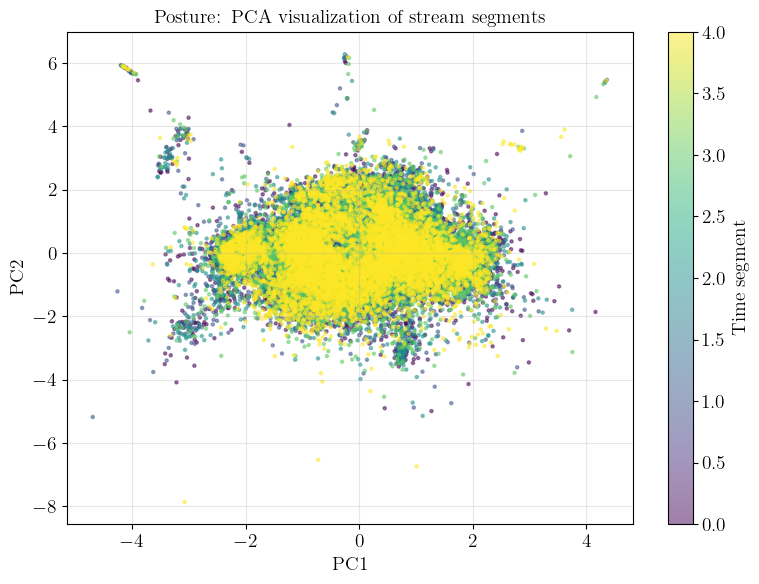

Explained variance ratio: [0.49083685 0.34090924]
Total explained variance: 0.8317460893363415


In [18]:
N_PLOT = min(40000, len(X))

X_vis = X[:N_PLOT]
t_plot = np.arange(len(X_vis))

X_scaled = StandardScaler().fit_transform(X_vis)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

segment_size = len(X_vis) // 5
segments = np.minimum(
    t_plot // segment_size,
    4,
)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=segments,
    s=5,
    alpha=0.5,
)

plt.title("Posture: PCA visualization of stream segments")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Time segment")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

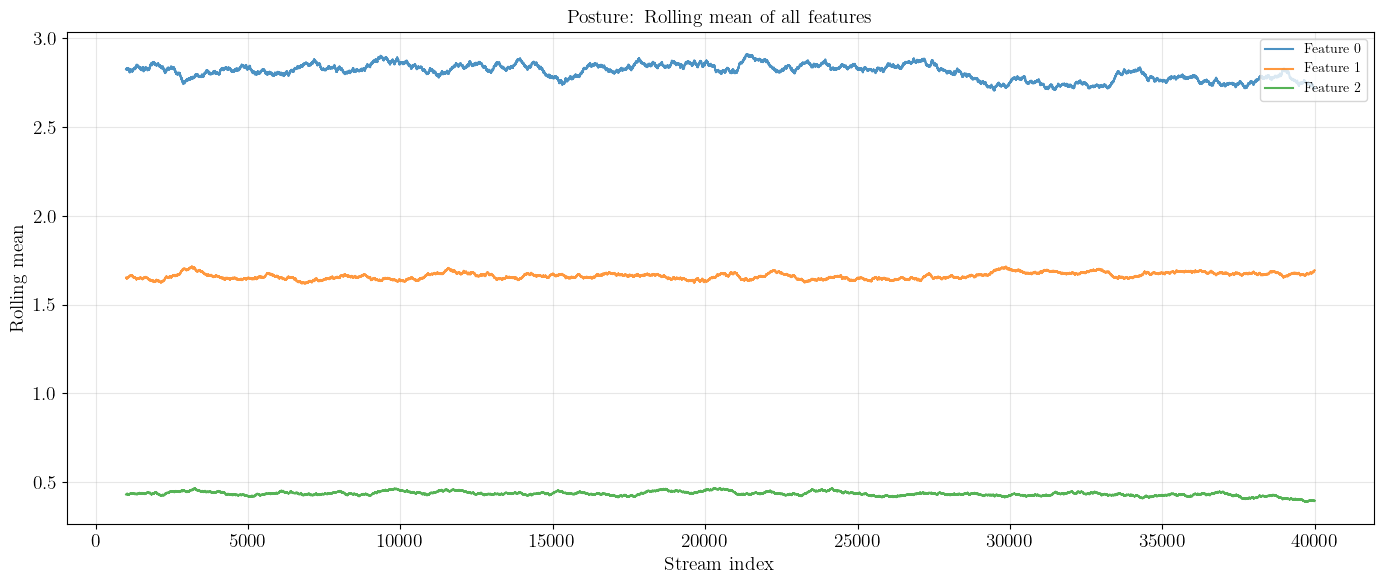

In [19]:
FEATURE_ROLLING_WINDOW = 1000

X_df = pd.DataFrame(X_vis)

rolling_feature_means = (
    X_df
    .rolling(FEATURE_ROLLING_WINDOW)
    .mean()
)

plt.figure(figsize=(14, 6))

for feature in rolling_feature_means.columns:
    plt.plot(
        rolling_feature_means.index,
        rolling_feature_means[feature],
        linewidth=1.5,
        alpha=0.8,
        label=f"Feature {feature}",
    )

plt.title("Posture: Rolling mean of all features")
plt.xlabel("Stream index")
plt.ylabel("Rolling mean")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Run STUDD with each detector

Each STUDD detector is evaluated independently.

For every detector, the Posture stream is recreated, the same teacher is trained and the same student configuration is used.

Only the drift detector inside STUDD changes.

Teacher-student disagreement is explicitly recorded at every monitoring sample.

In [20]:
comparison_runs = {}

for detector_name, detector_factory in DETECTORS.items():

    print(f"Running {detector_name}...")

    stream = NumpyStream(
        X,
        y,
        dataset_name="Posture",
    )

    schema = stream.get_schema()

    teacher = make_teacher(
        schema=schema,
        teacher_type=TEACHER_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    for _ in range(W):
        inst = stream.next_instance()
        teacher.train(inst)

    student = make_student(
        schema=schema,
        student_type=STUDENT_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    studd = STUDD(
        student=student,
        min_n_instances=W,
        detector=detector_factory(),
    )

    records = []
    studd_drift_points = []

    processed = W

    while stream.has_more_instances() and processed < N_STREAM:

        inst = stream.next_instance()

        y_true = inst.y_index
        y_teacher = teacher.predict(inst)

        if y_teacher is None:
            processed += 1
            continue

        y_student = student.predict(inst)

        if y_student is None:
            agreement = np.nan
            disagreement = np.nan
        else:
            agreement = int(y_student == y_teacher)
            disagreement = 1 - agreement

        teacher_correct = int(y_teacher == y_true)

        studd.add_element(
            inst,
            y_teacher,
        )

        detected_change = studd.detected_change()

        if detected_change:
            studd_drift_points.append(int(processed))

        records.append({
            "t": int(processed),
            "teacher_correct": teacher_correct,
            "agreement": agreement,
            "disagreement": disagreement,
            "drift_alarm": detected_change,
        })

        processed += 1

    results = pd.DataFrame(records)

    first_alarm = (
        studd_drift_points[0]
        if studd_drift_points
        else None
    )

    closest_alarm = (
        min(
            studd_drift_points,
            key=lambda alarm: abs(alarm - reference_drift),
        )
        if studd_drift_points
        else None
    )

    closest_alarm_delay = (
        closest_alarm - reference_drift
        if closest_alarm is not None
        else None
    )

    reference_before = results[
        (results["t"] >= reference_drift - LOCAL_WINDOW)
        &
        (results["t"] < reference_drift)
    ]["disagreement"].dropna()

    reference_after = results[
        (results["t"] >= reference_drift)
        &
        (results["t"] < reference_drift + LOCAL_WINDOW)
    ]["disagreement"].dropna()

    reference_disagreement_before = (
        reference_before.mean()
        if len(reference_before)
        else np.nan
    )

    reference_disagreement_after = (
        reference_after.mean()
        if len(reference_after)
        else np.nan
    )

    reference_disagreement_delta = (
        reference_disagreement_after - reference_disagreement_before
        if (
            not np.isnan(reference_disagreement_before)
            and not np.isnan(reference_disagreement_after)
        )
        else np.nan
    )

    if closest_alarm is not None:

        alarm_before = results[
            (results["t"] >= closest_alarm - LOCAL_WINDOW)
            &
            (results["t"] < closest_alarm)
        ]["disagreement"].dropna()

        alarm_after = results[
            (results["t"] >= closest_alarm)
            &
            (results["t"] < closest_alarm + LOCAL_WINDOW)
        ]["disagreement"].dropna()

        closest_alarm_disagreement_before = (
            alarm_before.mean()
            if len(alarm_before)
            else np.nan
        )

        closest_alarm_disagreement_after = (
            alarm_after.mean()
            if len(alarm_after)
            else np.nan
        )

        closest_alarm_disagreement_delta = (
            closest_alarm_disagreement_after
            - closest_alarm_disagreement_before
            if (
                not np.isnan(closest_alarm_disagreement_before)
                and not np.isnan(closest_alarm_disagreement_after)
            )
            else np.nan
        )

    else:

        closest_alarm_disagreement_before = np.nan
        closest_alarm_disagreement_after = np.nan
        closest_alarm_disagreement_delta = np.nan

    summary = {
        "detector": detector_name,

        "num_alarms": len(studd_drift_points),
        "alarms": studd_drift_points,

        "closest_alarm": closest_alarm,
        "closest_alarm_delay_from_ss": closest_alarm_delay,

        "reference_disagreement_delta": reference_disagreement_delta,

        "closest_alarm_disagreement_delta": closest_alarm_disagreement_delta,
    }

    comparison_runs[detector_name] = {
        "summary": summary,
        "results": results,
        "studd_drift_points": studd_drift_points,
    }

print("Done.")

Running ADWIN...


Running PageHinkley...
Running HDDMAverage...
Running HDDMWeighted...
Running CUSUM...
Done.


## Summary table

This table contains the main metrics collected for each STUDD detector.

The main reference point is the first SS alarm.

In [21]:
summary_df = pd.DataFrame([
    run["summary"]
    for run in comparison_runs.values()
])

summary_df["abs_closest_alarm_delay_from_ss"] = (
    summary_df["closest_alarm_delay_from_ss"]
    .abs()
)

summary_df = (
    summary_df
    .sort_values(
        "abs_closest_alarm_delay_from_ss",
        na_position="last",
    )
    .reset_index(drop=True)
)

summary_df

,detector,num_alarms,alarms,closest_alarm,closest_alarm_delay_from_ss,reference_disagreement_delta,closest_alarm_disagreement_delta,abs_closest_alarm_delay_from_ss
0,PageHinkley,5,"[10374, 24739, 45003, 72964, 129021]",24739,330,-0.06,0.060000,330
1,HDDMWeighted,1,[25265],25265,856,-0.06,0.040000,856
2,CUSUM,5,"[10318, 25469, 48237, 74892, 129724]",25469,1060,-0.06,0.090000,1060
3,ADWIN,18,"[11518, 11902, 12574, 13694, 36670, 46622, 493...",13694,-10715,-0.06,0.071919,10715
4,HDDMAverage,3,"[12269, 49037, 151238]",12269,-12140,-0.06,0.040000,12140


## Typical drift detection metrics

This section computes classic drift detection metrics using the first SS alarm as the reference drift point.

Following the STUDD paper, alarms occurring more than `W` observations before the first SS alarm are considered false alarms.

Alarms occurring from `first SS alarm - W` onward are considered true drift alarms.

If a detector has no true drift alarm, it is considered to have missed the drift.

These metrics are computed per dataset and per detector.

In [22]:
DATASET_NAME = "Posture"  

if len(ss_drift_points) == 0:
    raise ValueError(
        "SS did not trigger any alarm. "
        "This dataset cannot be used for SS-reference detection metrics."
    )

detection_metric_rows = []

valid_detection_start = reference_drift - W

for detector_name, run in comparison_runs.items():

    alarms = run["studd_drift_points"]

    false_alarms = [
        alarm
        for alarm in alarms
        if alarm < valid_detection_start
    ]

    true_drift_alarms = [
        alarm
        for alarm in alarms
        if alarm >= valid_detection_start
    ]

    if len(true_drift_alarms) == 0:

        missed_detection = 1
        first_true_detection = np.nan
        signed_detection_delay = np.nan
        detection_delay_for_mtd = np.nan
        normalized_detection_delay = np.nan

    else:

        missed_detection = 0

        # First alarm that qualifies as a true detection
        first_true_detection = int(min(true_drift_alarms))

        # Signed delay:
        # negative = detector alarmed before SS
        # positive = detector alarmed after SS
        signed_detection_delay = first_true_detection - reference_drift

        # For MTD, early detections are not penalized
        detection_delay_for_mtd = max(0, signed_detection_delay)

        normalized_detection_delay = (
            detection_delay_for_mtd / N_STREAM
        )

    has_false_alarm = int(len(false_alarms) > 0)

    if len(false_alarms) >= 2:

        false_alarm_intervals = np.diff(false_alarms)

        mean_time_between_false_alarms = float(
            np.mean(false_alarm_intervals)
        )

        normalized_mtfa = (
            mean_time_between_false_alarms / N_STREAM
        )

    else:

        mean_time_between_false_alarms = np.nan
        normalized_mtfa = np.nan

    detection_metric_rows.append({
        "dataset": DATASET_NAME,
        "detector": detector_name,

        "N_STREAM": N_STREAM,
        "W": W,
        "reference_drift": reference_drift,
        "valid_detection_start": valid_detection_start,

        "alarms": alarms,
        "num_alarms": len(alarms),

        "false_alarms": false_alarms,
        "num_false_alarms": len(false_alarms),
        "has_false_alarm": has_false_alarm,

        "true_drift_alarms": true_drift_alarms,
        "missed_detection": missed_detection,

        "first_true_detection": first_true_detection,
        "signed_detection_delay": signed_detection_delay,
        "detection_delay_for_mtd": detection_delay_for_mtd,
        "normalized_detection_delay": normalized_detection_delay,

        "mean_time_between_false_alarms": mean_time_between_false_alarms,
        "normalized_mtfa": normalized_mtfa,
    })

detection_metrics_df = pd.DataFrame(detection_metric_rows)

detection_metrics_df

,dataset,detector,N_STREAM,W,reference_drift,valid_detection_start,alarms,num_alarms,false_alarms,num_false_alarms,has_false_alarm,true_drift_alarms,missed_detection,first_true_detection,signed_detection_delay,detection_delay_for_mtd,normalized_detection_delay,mean_time_between_false_alarms,normalized_mtfa
0,Posture,ADWIN,164860,2000,24409,22409,"[11518, 11902, 12574, 13694, 36670, 46622, 493...",18,"[11518, 11902, 12574, 13694]",4,1,"[36670, 46622, 49374, 61246, 68510, 79038, 807...",0,36670,12261,12261,0.074372,725.333333,0.0044
1,Posture,PageHinkley,164860,2000,24409,22409,"[10374, 24739, 45003, 72964, 129021]",5,[10374],1,1,"[24739, 45003, 72964, 129021]",0,24739,330,330,0.002002,NaN,NaN
2,Posture,HDDMAverage,164860,2000,24409,22409,"[12269, 49037, 151238]",3,[12269],1,1,"[49037, 151238]",0,49037,24628,24628,0.149387,NaN,NaN
3,Posture,HDDMWeighted,164860,2000,24409,22409,[25265],1,[],0,0,[25265],0,25265,856,856,0.005192,NaN,NaN
4,Posture,CUSUM,164860,2000,24409,22409,"[10318, 25469, 48237, 74892, 129724]",5,[10318],1,1,"[25469, 48237, 74892, 129724]",0,25469,1060,1060,0.006430,NaN,NaN


In [25]:
compact_detection_metrics_df = detection_metrics_df[
    [
        "dataset",
        "detector",
        "missed_detection",
        "has_false_alarm",
        "normalized_detection_delay",
        "normalized_mtfa",
        "num_alarms",
        "num_false_alarms",
    ]
].copy()

compact_detection_metrics_df

,dataset,detector,missed_detection,has_false_alarm,normalized_detection_delay,normalized_mtfa,num_alarms,num_false_alarms
0,Posture,ADWIN,0,1,0.074372,0.0044,18,4
1,Posture,PageHinkley,0,1,0.002002,NaN,5,1
2,Posture,HDDMAverage,0,1,0.149387,NaN,3,1
3,Posture,HDDMWeighted,0,0,0.005192,NaN,1,0
4,Posture,CUSUM,0,1,0.006430,NaN,5,1


In [26]:
compact_detection_metrics_df.to_dict("records")

[{'dataset': 'Posture',
  'detector': 'ADWIN',
  'missed_detection': 0,
  'has_false_alarm': 1,
  'normalized_detection_delay': 0.07437219458934854,
  'normalized_mtfa': 0.004399692668526831,
  'num_alarms': 18,
  'num_false_alarms': 4},
 {'dataset': 'Posture',
  'detector': 'PageHinkley',
  'missed_detection': 0,
  'has_false_alarm': 1,
  'normalized_detection_delay': 0.002001698410772777,
  'normalized_mtfa': nan,
  'num_alarms': 5,
  'num_false_alarms': 1},
 {'dataset': 'Posture',
  'detector': 'HDDMAverage',
  'missed_detection': 0,
  'has_false_alarm': 1,
  'normalized_detection_delay': 0.14938735897124833,
  'normalized_mtfa': nan,
  'num_alarms': 3,
  'num_false_alarms': 1},
 {'dataset': 'Posture',
  'detector': 'HDDMWeighted',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.005192284362489385,
  'normalized_mtfa': nan,
  'num_alarms': 1,
  'num_false_alarms': 0},
 {'dataset': 'Posture',
  'detector': 'CUSUM',
  'missed_detection': 0,
  'has_fa

## Rolling teacher accuracy

The following plots show the rolling teacher accuracy for each detector run.

The first SS alarm is shown as a purple dashed line.

STUDD alarms are shown as red dotted lines.

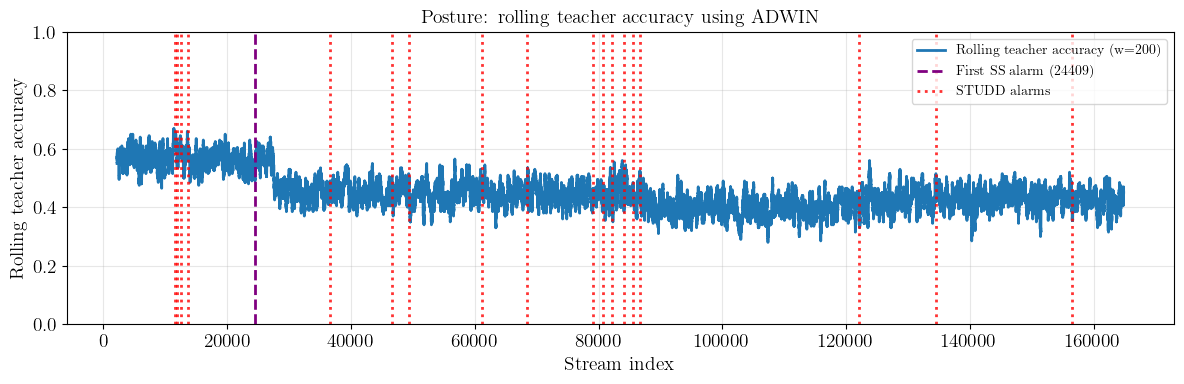

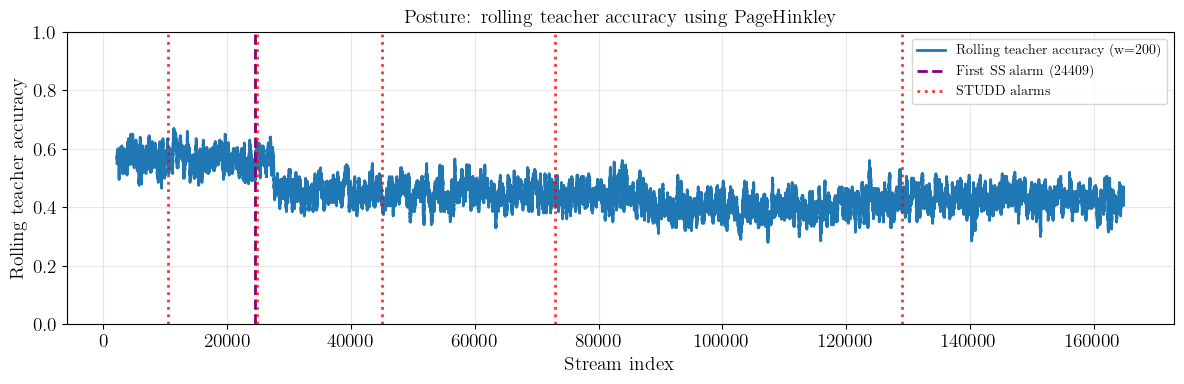

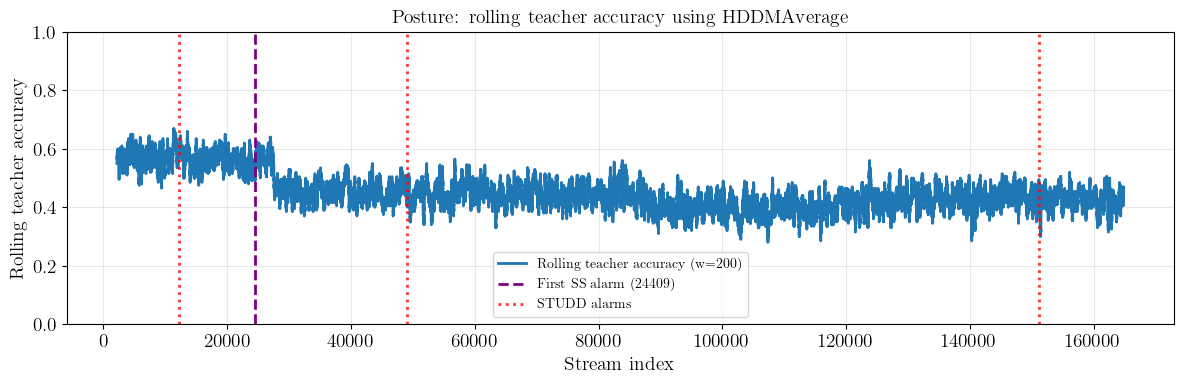

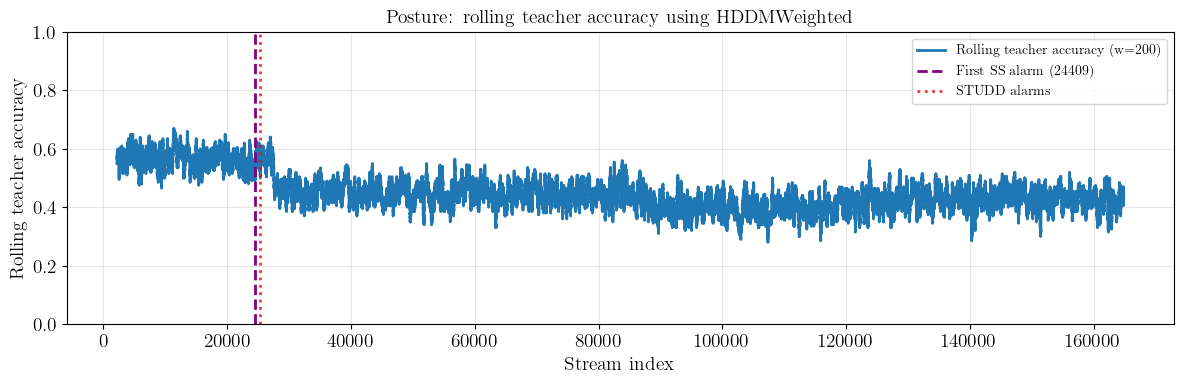

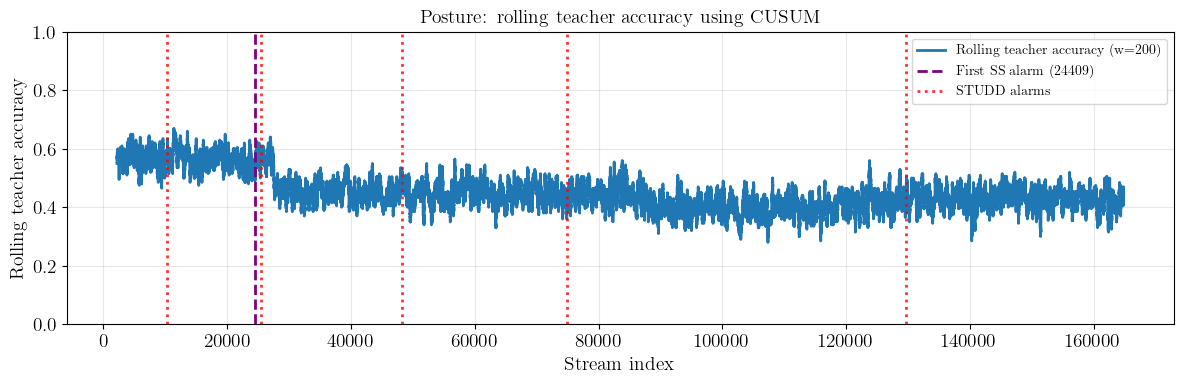

In [23]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    rolling_accuracy, _ = rolling_mean(
        results["teacher_correct"].to_numpy(dtype=float),
        ROLLING_WINDOW,
    )

    rolling_t = results["t"].to_numpy()[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_accuracy,
        linewidth=2,
        label=f"Rolling teacher accuracy (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"Posture: rolling teacher accuracy using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling teacher accuracy")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Rolling teacher-student disagreement

The following plots show rolling teacher-student disagreement for each detector.

This is the signal monitored by STUDD.

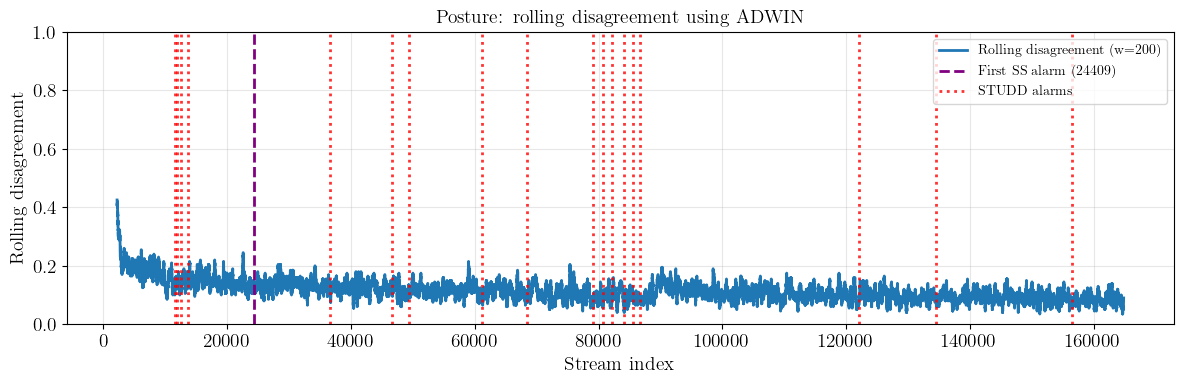

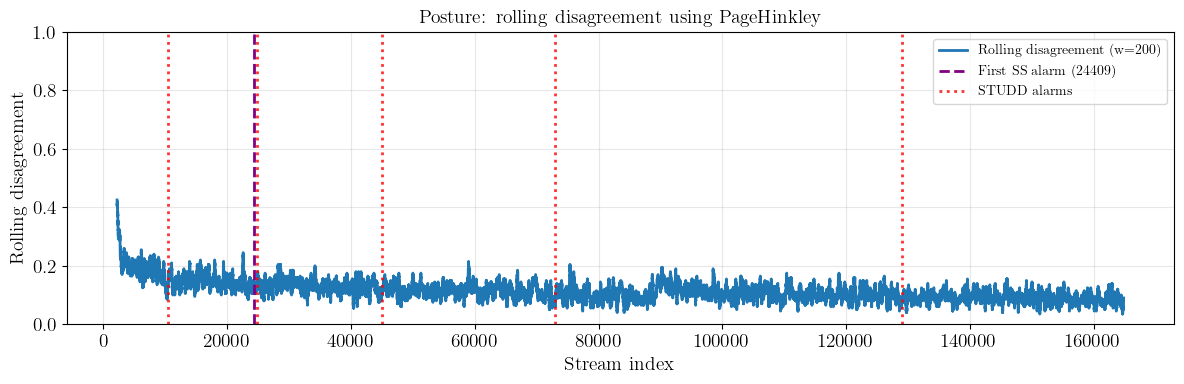

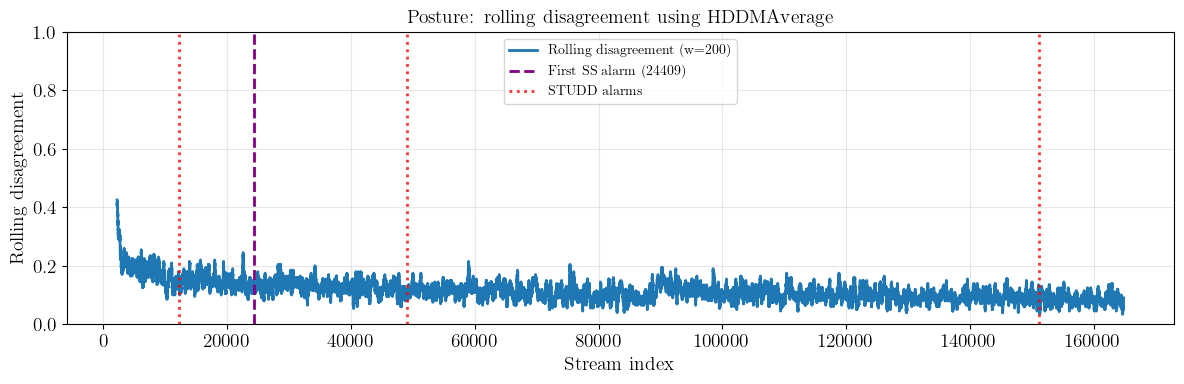

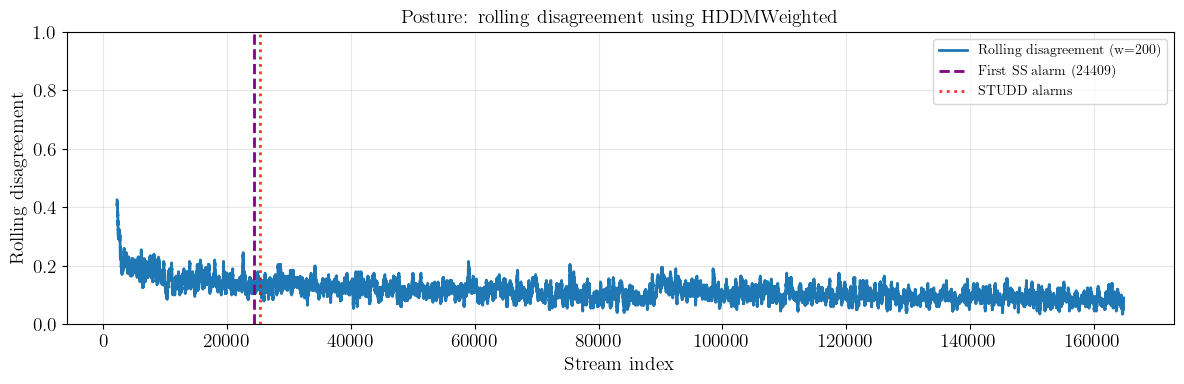

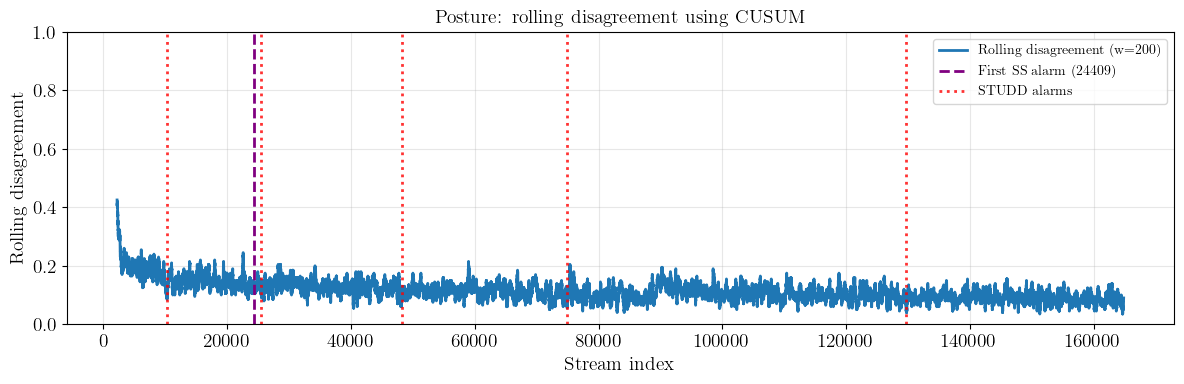

In [24]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    valid_results = results.dropna(subset=["disagreement"])

    rolling_disagreement, _ = rolling_mean(
        valid_results["disagreement"].to_numpy(dtype=float),
        ROLLING_WINDOW,
    )

    rolling_t = valid_results["t"].to_numpy()[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_disagreement,
        linewidth=2,
        label=f"Rolling disagreement (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"Posture: rolling disagreement using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling disagreement")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Detector comparison summary

This notebook compares the effect of changing the detector inside STUDD on the Posture dataset.

The first SS alarm is used as a reference drift indication.

The key quantities are:

- closest alarm delay from ss : how close the STUDD detector came to the SS reference alarm
- alarms before first ss : whether STUDD raised alarms before the supervised reference point
- number of alarms : whether the detector is too sensitive
- reference disagreement delta : whether disagreement changes around the first SS alarm
- closest alarm disagreement delta : whether disagreement changes around the closest STUDD alarm